In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments


In [24]:
import pandas as pd
import json
import gzip

def load_amazon_json_sample(file_path, max_lines=100000):
    data = []
    with gzip.open(file_path, "rt", encoding="utf-8") as f:  # Use gzip to open the file
        for i, line in enumerate(f):
            if i >= max_lines:  # Stop if the maximum lines are reached
                break
            data.append(json.loads(line.strip()))  # Parse each line as JSON
    return pd.DataFrame(data)

# Provide the correct path to the JSONL file on your Google Drive
file_path = '/content/drive/My Drive/Electronics.jsonl (1).gz'
df = load_amazon_json_sample(file_path, max_lines=100000)

# Print the columns and first few rows
print("Columns:", df.columns.tolist())
print(df.head(3))


Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
   rating                                    title  \
0     3.0        Smells like gasoline! Going back!   
1     1.0  Didn’t work at all lenses loose/broken.   
2     5.0                               Excellent!   

                                                text  \
0  First & most offensive: they reek of gasoline ...   
1  These didn’t work. Idk if they were damaged in...   
2  I love these. They even come with a carry case...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM   
1                                                 []  B07N69T6TM  B07N69T6TM   
2                                                 []  B01G8JO5F2  B01G8JO5F2   

                        user_id      timestamp  helpful_vote  \
0  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  165818511

In [25]:
df.shape

(100000, 10)

In [14]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["clean_text"] = df["text"].apply(clean_text)
df["sentiment"] = df["rating"].apply(map_sentiment)

print(df[["rating", "sentiment", "clean_text"]].sample(5))


       rating sentiment                                         clean_text
61097     1.0  negative  installed correctly first press and cracked ve...
27046     5.0  positive  this portable monitor worked great on both mac...
21913     4.0  positive  i bought this for my ipad pro 11 with the magi...
86102     5.0  positive  this is so much better than the window mount w...
20299     1.0  negative  i have been working with security camera produ...


In [19]:
import pandas as pd
import json
import gzip

def load_amazon_json_sample(file_path, max_lines=100000):
    data = []
    with gzip.open(file_path, "rt", encoding="utf-8") as f:  # Use gzip to open the file
        for i, line in enumerate(f):
            if i >= max_lines:
                break
            data.append(json.loads(line))  # Parse each line as JSON
    return pd.DataFrame(data)

# Provide the correct path to the JSONL file on your Google Drive
meta_df = load_amazon_json_sample("/content/drive/My Drive/meta_Electronics.jsonl (1).gz", max_lines=100000)

# Print the columns and first few rows
print("Columns:", df.columns.tolist())
print(df.head(3))


Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
     main_category                                              title  \
0  All Electronics             FS-1051 FATSHARK TELEPORTER V3 HEADSET   
1  All Electronics                      Ce-H22B12-S1 4Kx2K Hdmi 4Port   
2        Computers  Digi-Tatoo Decal Skin Compatible With MacBook ...   

   average_rating  rating_number  \
0             3.5              6   
1             5.0              1   
2             4.5            246   

                                            features  \
0                                                 []   
1             [UPC: 662774021904, Weight: 0.600 lbs]   
2  [WARNING: Please IDENTIFY MODEL NUMBER on the ...   

                                         description  price  \
0  [Teleporter V3 The “Teleporter V3” kit sets a ...   No

In [20]:
meta_df.shape

(100000, 16)

In [26]:
print("df columns:", df.columns)
print("meta_df columns:", meta_df.columns)


df columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')
meta_df columns: Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
      dtype='object')


In [28]:
merged_df = pd.merge(df, meta_df, left_on="asin", right_on="parent_asin", how="left")

print(merged_df[["asin", "title_x", "title_y", "main_category", "categories"]].sample(5))

             asin                                        title_x title_y  \
60484  B00EON40CS                        Great for a 3D printer.     NaN   
29924  B0043XOFMO                                       exellent     NaN   
98481  B07P57CJK5  HTKO. Gorgeous high-tech KNOCKOUT of a watch!     NaN   
3760   B003SWLRLS                                      The Best!     NaN   
68768  B0BRC4XV1H                                  Love these 😍🙌     NaN   

      main_category categories  
60484           NaN        NaN  
29924           NaN        NaN  
98481           NaN        NaN  
3760            NaN        NaN  
68768           NaN        NaN  


In [29]:
merged_df = pd.merge(df, meta_df, left_on="parent_asin", right_on="parent_asin", how="left")


In [30]:
print("Review ASINs:", df["asin"].nunique())
print("Meta Parent ASINs:", meta_df["parent_asin"].nunique())

print("Overlap:", len(set(df["asin"]).intersection(set(meta_df["parent_asin"]))))


Review ASINs: 66260
Meta Parent ASINs: 100000
Overlap: 2459


In [31]:
def final_reassign(row):
    title = str(row.get("title_y", "")).lower()

    if any(keyword in title for keyword in ["monitor", "laptop", "usb", "ethernet", "hdmi", "cable", "router", "cooler", "mount"]):
        return "Computers"
    elif any(keyword in title for keyword in ["earbuds", "headphones", "soundbar", "bluetooth speaker"]):
        return "Home Audio & Theater"
    elif "kindle" in title:
        return "Amazon Devices"
    elif any(keyword in title for keyword in ["charger", "power strip", "outlet"]):
        return "Computers"
    elif "tv" in title or "roku" in title:
        return "Home Audio & Theater"
    elif "smartwatch" in title or "fitbit" in title:
        return "Cell Phones & Accessories"
    else:
        return row.get("main_category_refined", "Unknown")



In [32]:
print(merged_df.columns.tolist())


['rating', 'title_x', 'text', 'images_x', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'main_category', 'title_y', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images_y', 'videos', 'store', 'categories', 'details', 'bought_together', 'subtitle', 'author']


In [33]:
merged_df["main_category_refined"] = merged_df["main_category"]


In [34]:
mask = merged_df["main_category_refined"] == "Other Electronics"
merged_df.loc[mask, "main_category_refined"] = merged_df[mask].apply(final_reassign, axis=1)


In [35]:
def refine_category(row):
    title = str(row["title_y"]).lower()
    cats = " - ".join(row["categories"]).lower() if isinstance(row["categories"], list) else ""

    if "laptop" in title or "computer" in cats:
        return "Computers"
    elif "headphones" in cats or "speaker" in title:
        return "Home Audio & Theater"
    elif "phone" in title or "cell" in cats:
        return "Cell Phones & Accessories"
    elif "camera" in cats or "dslr" in title:
        return "Camera & Photo"
    elif "projector" in cats or "hdmi" in title:
        return "Home Audio & Theater"
    elif "usb" in title or "storage" in title:
        return "Computers"
    elif "kindle" in title or "tablet" in title:
        return "Amazon Devices"
    else:
        return row["main_category_refined"]  # fallback to previous

# ✅ Apply it
merged_df["main_category_refined"] = merged_df.apply(refine_category, axis=1)



In [36]:
category_counts = merged_df["main_category_refined"].value_counts()

print("Final Category Counts:\n")
print(category_counts)


Final Category Counts:

main_category_refined
Computers                       8324
Home Audio & Theater            2906
Amazon Devices                  1606
Camera & Photo                  1311
All Electronics                  913
Cell Phones & Accessories        896
Tools & Home Improvement         149
AMAZON FASHION                    75
Industrial & Scientific           64
Sports & Outdoors                 61
Office Products                   53
Amazon Home                       38
Apple Products                    31
Car Electronics                   29
Automotive                        29
Health & Personal Care            12
GPS & Navigation                  11
Amazon Fire TV                     8
Musical Instruments                7
Video Games                        6
Grocery                            6
Software                           4
Toys & Games                       4
Portable Audio & Accessories       2
Books                              1
Appliances                   

In [37]:
top_categories = merged_df["main_category_refined"].value_counts().head(10).index
filtered_df = merged_df[merged_df["main_category_refined"].isin(top_categories)]



In [41]:
merged_df["sentiment"] = merged_df["rating_number"].apply(map_sentiment)


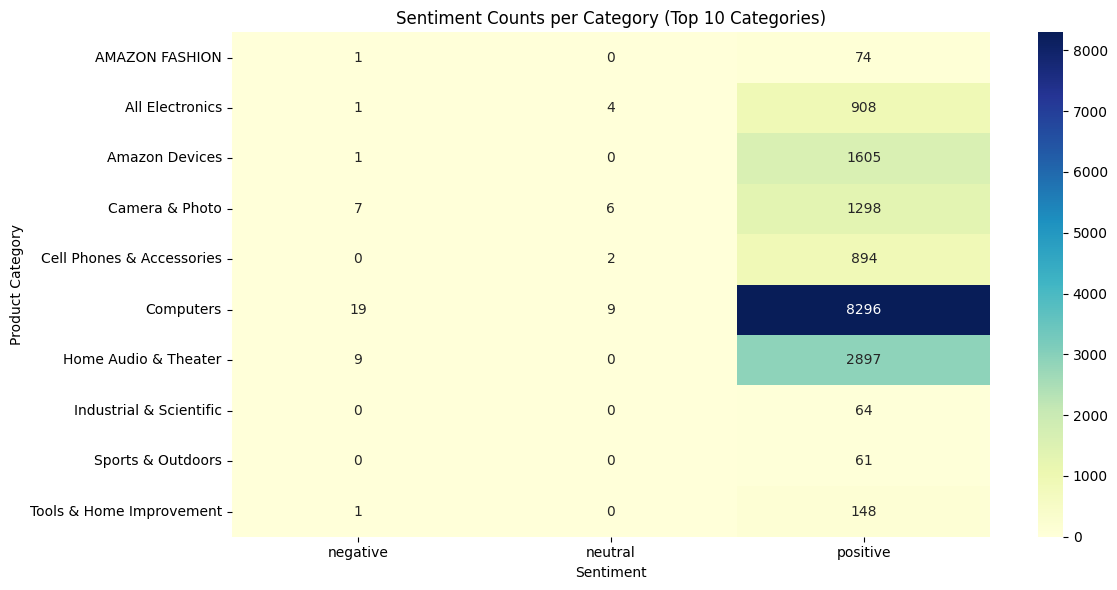

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top10_cats = merged_df["main_category_refined"].value_counts().head(10).index
top10_df = merged_df[merged_df["main_category_refined"].isin(top10_cats)]

# Create cross-tab (absolute counts)
conf_matrix = pd.crosstab(
    top10_df["main_category_refined"],
    top10_df["sentiment"]
)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Sentiment Counts per Category (Top 10 Categories)")
plt.xlabel("Sentiment")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


In [56]:
from sklearn.utils import resample

# Separate classes
positive_df = merged_df[merged_df["sentiment"] == "positive"]
negative_df = merged_df[merged_df["sentiment"] == "negative"]
neutral_df  = merged_df[merged_df["sentiment"] == "neutral"]

# Upsample negative and neutral to match positive count
negative_upsampled = resample(negative_df, replace=True, n_samples=len(positive_df), random_state=42)
neutral_upsampled  = resample(neutral_df,  replace=True, n_samples=len(positive_df), random_state=42)

# Combine all
final_balanced_df = pd.concat([positive_df, negative_upsampled, neutral_upsampled])

# Shuffle
final_balanced_df = final_balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check counts
print(final_balanced_df["sentiment"].value_counts())


sentiment
negative    99935
neutral     99935
positive    99935
Name: count, dtype: int64


In [57]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}
final_balanced_df["label"] = final_balanced_df["sentiment"].map(label_map)

In [52]:
from sklearn.utils import resample

# Separate by class
positive = merged_df[merged_df["sentiment"] == "positive"]
neutral = merged_df[merged_df["sentiment"] == "neutral"]
negative = merged_df[merged_df["sentiment"] == "negative"]

# Downsample positive to match minority
positive_downsampled = resample(positive, replace=False, n_samples=len(negative), random_state=42)

# Combine into balanced dataset
balanced_df = pd.concat([positive_downsampled, neutral, negative])


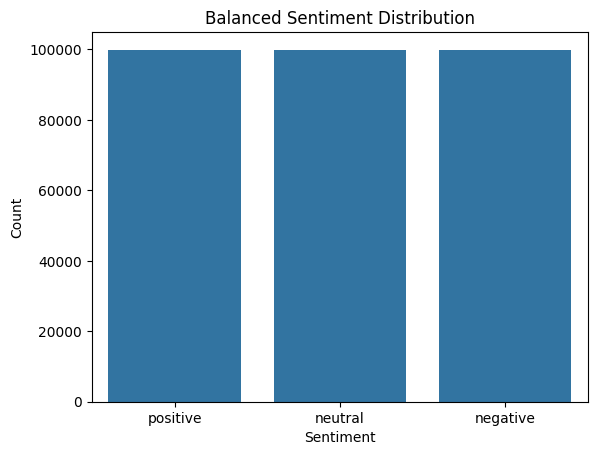

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=final_balanced_df, x="sentiment", order=["positive", "neutral", "negative"])
plt.title("Balanced Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [60]:
from sklearn.utils import resample

# Separate by class
positive = merged_df[merged_df["sentiment"] == "positive"]
neutral = merged_df[merged_df["sentiment"] == "neutral"]
negative = merged_df[merged_df["sentiment"] == "negative"]

# Downsample positive to match minority
positive_downsampled = resample(positive, replace=False, n_samples=len(negative), random_state=42)

# Combine into balanced dataset
balanced_df = pd.concat([positive_downsampled, neutral, negative])


In [61]:
from sklearn.utils import resample

# Separate classes
positive_df = merged_df[merged_df["sentiment"] == "positive"]
negative_df = merged_df[merged_df["sentiment"] == "negative"]
neutral_df  = merged_df[merged_df["sentiment"] == "neutral"]

# Upsample negative and neutral to match positive count
negative_upsampled = resample(negative_df, replace=True, n_samples=len(positive_df), random_state=42)
neutral_upsampled  = resample(neutral_df,  replace=True, n_samples=len(positive_df), random_state=42)

# Combine all
final_balanced_df = pd.concat([positive_df, negative_upsampled, neutral_upsampled])

# Shuffle
final_balanced_df = final_balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check counts
print(final_balanced_df["sentiment"].value_counts())


sentiment
negative    99935
neutral     99935
positive    99935
Name: count, dtype: int64


In [62]:
# Map sentiment to numerical labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
final_balanced_df["label"] = final_balanced_df["sentiment"].map(label_map)


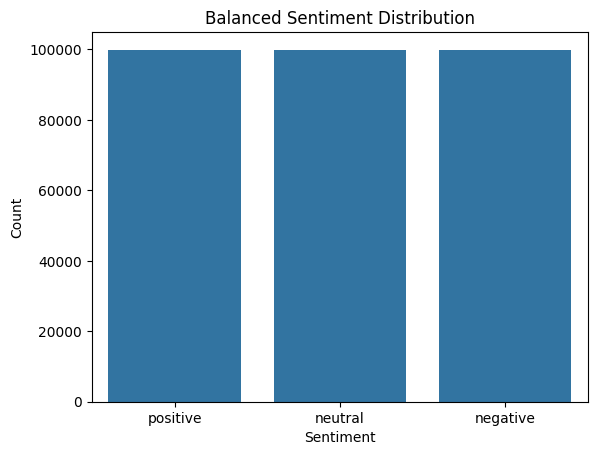

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=final_balanced_df, x="sentiment", order=["positive", "neutral", "negative"])
plt.title("Balanced Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [64]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/improved_model_roberta"


# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

In [67]:
label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}


In [68]:
from transformers import pipeline

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

examples = [
    "I absolutely love this! Highly recommend it to everyone.",
    "It's okay, nothing special but not bad either.",
    "Terrible experience. Will never buy this again.",
    "The quality exceeded my expectations.",
    "Meh, it’s average. I don’t feel strongly about it.",
    "Worst product I’ve ever purchased.",
    "Great value for the price!",
    "Not worth the money.",
    "I’m satisfied but not impressed.",
    "Awful packaging and very slow shipping."
]

for text in examples:
    result = classifier(text)[0]
    label = label_map[result["label"]]
    print(f"{label.upper()} ({result['score']:.2f}) → {text}")


Device set to use cpu


POSITIVE (1.00) → I absolutely love this! Highly recommend it to everyone.
NEUTRAL (0.86) → It's okay, nothing special but not bad either.
NEGATIVE (0.99) → Terrible experience. Will never buy this again.
POSITIVE (1.00) → The quality exceeded my expectations.
NEUTRAL (0.93) → Meh, it’s average. I don’t feel strongly about it.
NEGATIVE (0.99) → Worst product I’ve ever purchased.
POSITIVE (1.00) → Great value for the price!
NEGATIVE (0.99) → Not worth the money.
NEUTRAL (0.87) → I’m satisfied but not impressed.
NEGATIVE (0.98) → Awful packaging and very slow shipping.


In [70]:
import gradio as gr

# Define sentiment mapping
label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

# Define prediction function
def classify_sentiment(text):
    result = classifier(text)[0]
    label = label_map[result["label"]]
    score = round(result["score"], 2)
    return f"{label.upper()} (confidence: {score})"

# Gradio interface
demo = gr.Interface(
    fn=classify_sentiment,
    inputs=gr.Textbox(lines=4, placeholder="Enter your product review here..."),
    outputs="text",
    title="📦 Product Review Sentiment Classifier",
    description="Enter a product review and get its sentiment (Positive, Neutral, Negative) using a fine-tuned RoBERTa model."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://05fafca3ef678ee4d9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
